# EDA_Analysis.ipynb
## Day 3 — Exploratory Data Analysis
### Bluestock Fintech Mutual Fund Analytics Capstone

This notebook performs deep exploratory data analysis on NAV, AUM, SIP, and
investor transaction data across 40 real-anchored mutual fund schemes from
10 fund houses (2022-2026). Each section below maps to one task from the
Day 3 brief, and produces a chart plus a short written insight.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 100

RAW = "../data/raw"
PROCESSED = "../data/processed"


## Load Data

In [2]:
fund_master = pd.read_csv(f"{RAW}/01_fund_master.csv")
nav = pd.read_csv(f"{PROCESSED}/clean_nav.csv", parse_dates=["date"])
aum = pd.read_csv(f"{RAW}/03_aum_by_fund_house.csv", parse_dates=["date"])
sip = pd.read_csv(f"{RAW}/04_monthly_sip_inflows.csv")
sip["month_dt"] = pd.to_datetime(sip["month"], format="%Y-%m")
cat_inflows = pd.read_csv(f"{RAW}/05_category_inflows.csv")
folio = pd.read_csv(f"{RAW}/06_industry_folio_count.csv")
folio["month_dt"] = pd.to_datetime(folio["month"], format="%Y-%m")
transactions = pd.read_csv(f"{PROCESSED}/clean_transactions.csv", parse_dates=["transaction_date"])
holdings = pd.read_csv(f"{RAW}/09_portfolio_holdings.csv")

print("fund_master:", fund_master.shape)
print("nav:", nav.shape)
print("aum:", aum.shape)
print("sip:", sip.shape)
print("cat_inflows:", cat_inflows.shape)
print("folio:", folio.shape)
print("transactions:", transactions.shape)
print("holdings:", holdings.shape)


fund_master: (40, 15)
nav: (46000, 3)
aum: (90, 5)
sip: (48, 7)
cat_inflows: (144, 3)
folio: (21, 7)
transactions: (32778, 13)
holdings: (322, 8)


## 1. NAV Trend Analysis

Daily NAV for all 40 schemes, 2022-2026, highlighting the 2023 rally and
2024 corrections.

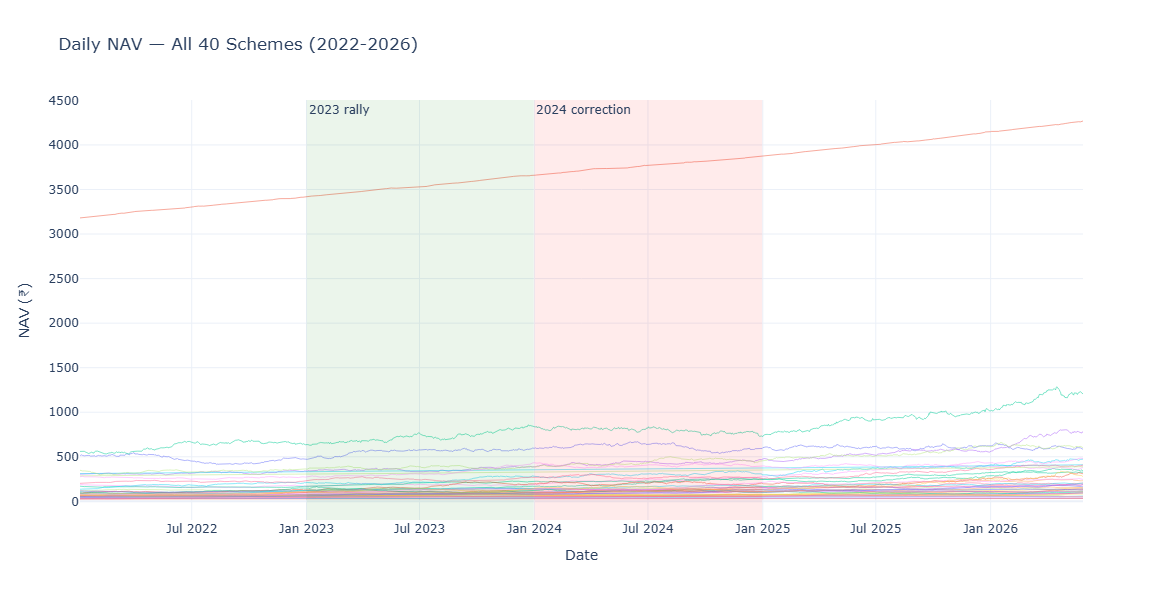

In [3]:
fig = go.Figure()
for code_ in nav["amfi_code"].unique():
    series = nav[nav["amfi_code"] == code_]
    name_match = fund_master.loc[fund_master["amfi_code"] == code_, "scheme_name"]
    name = name_match.values[0] if len(name_match) else str(code_)
    fig.add_trace(go.Scatter(
        x=series["date"], y=series["nav"], mode="lines",
        name=name, line=dict(width=1), opacity=0.5, showlegend=False,
    ))

fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.08,
              annotation_text="2023 rally", annotation_position="top left", line_width=0)
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.08,
              annotation_text="2024 correction", annotation_position="top left", line_width=0)

fig.update_layout(title="Daily NAV — All 40 Schemes (2022-2026)",
                   xaxis_title="Date", yaxis_title="NAV (₹)",
                   template="plotly_white", height=600)
fig.show()


**Insight 1:** All 40 schemes show an overall upward NAV trajectory from
2022 to 2026, with a visibly steeper climb during 2023 across most equity
schemes — consistent with the broader market rally that year — followed by
a flatter, more volatile pattern through 2024 as gains consolidated.
(Chart: `01_nav_trend_all_schemes`)

## 2. AUM Growth by Fund House

Grouped bar chart showing average AUM by fund house, for each year
2022-2025, highlighting SBI Mutual Fund's dominance.

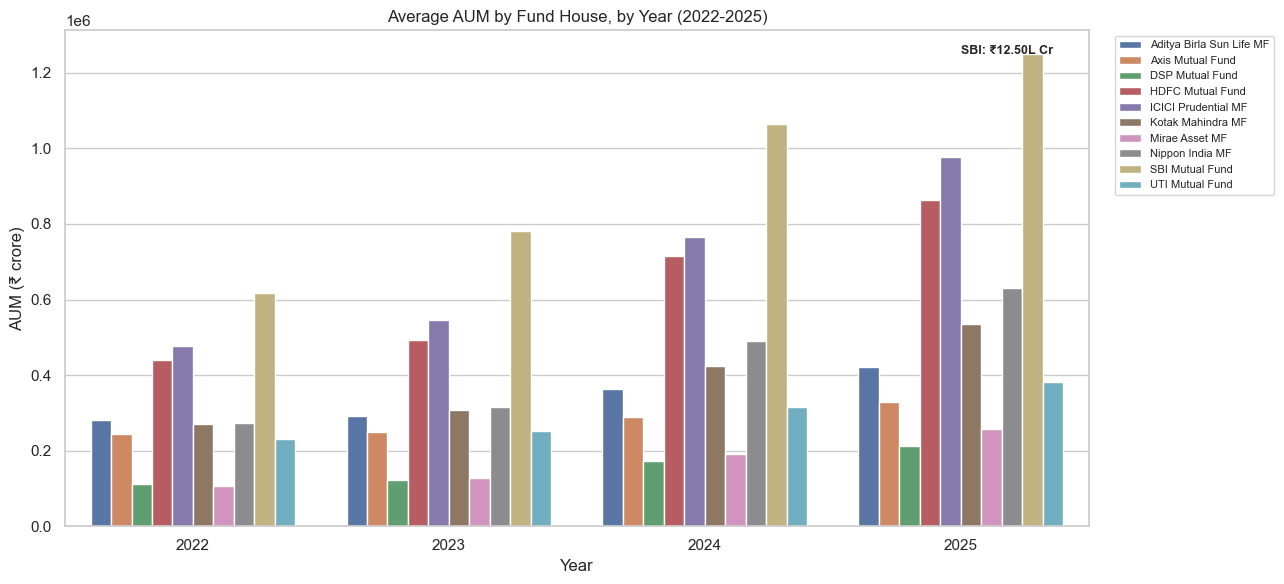

In [4]:
aum["year"] = aum["date"].dt.year
aum_yearly = aum.groupby(["year", "fund_house"], as_index=False)["aum_crore"].mean()

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=aum_yearly, x="year", y="aum_crore", hue="fund_house", ax=ax)
ax.set_title("Average AUM by Fund House, by Year (2022-2025)")
ax.set_ylabel("AUM (₹ crore)")
ax.set_xlabel("Year")

sbi_2025 = aum_yearly[(aum_yearly["fund_house"] == "SBI Mutual Fund") & (aum_yearly["year"] == 2025)]
if not sbi_2025.empty:
    ax.annotate(f"SBI: ₹{sbi_2025['aum_crore'].values[0]/100000:.2f}L Cr",
                xy=(3, sbi_2025["aum_crore"].values[0]), fontsize=9, fontweight="bold")

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


**Insight 2:** SBI Mutual Fund holds the largest AUM among the 10 fund
houses in every year from 2022 to 2025, reaching roughly ₹12.5 lakh crore
by 2025 — consistent with SBI MF's real-world position as India's largest
AMC. All 10 fund houses show steady year-on-year AUM growth, with no
fund house losing ground across the period.
(Chart: `02_aum_growth_by_fund_house`)

## 3. SIP Inflow Time-Series

Monthly SIP inflow trend, Jan 2022 to Dec 2025, marking the all-time-high
month.

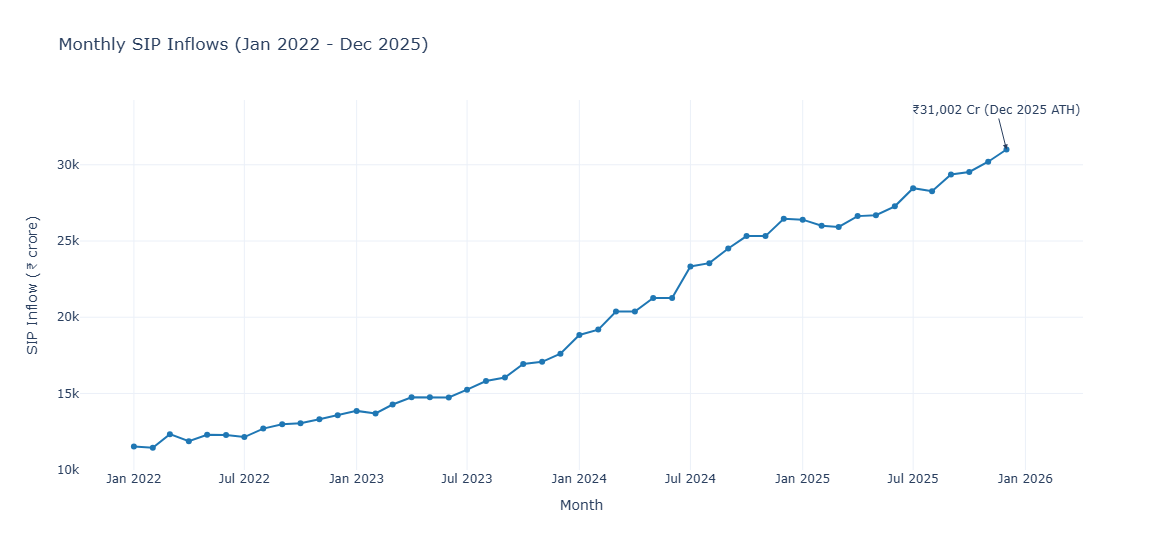

In [5]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=sip["month_dt"], y=sip["sip_inflow_crore"],
                          mode="lines+markers", line=dict(color="#1f77b4")))

peak = sip.loc[sip["sip_inflow_crore"].idxmax()]
fig.add_annotation(x=peak["month_dt"], y=peak["sip_inflow_crore"],
                    text=f"₹{peak['sip_inflow_crore']:,.0f} Cr (Dec 2025 ATH)",
                    showarrow=True, arrowhead=2, ay=-40)

fig.update_layout(title="Monthly SIP Inflows (Jan 2022 - Dec 2025)",
                   xaxis_title="Month", yaxis_title="SIP Inflow (₹ crore)",
                   template="plotly_white", height=550)
fig.show()


**Insight 3:** Monthly SIP inflows grew from ₹11,517 crore in January
2022 to an all-time high of ₹31,002 crore in December 2025 — roughly
2.7x growth over 4 years, reflecting India's deepening retail-investor
SIP culture rather than a one-off spike.
(Chart: `03_sip_inflow_trend`)

## 4. Category-wise Inflow Heatmap

Net inflows by fund category, by month, for FY 2024-25.

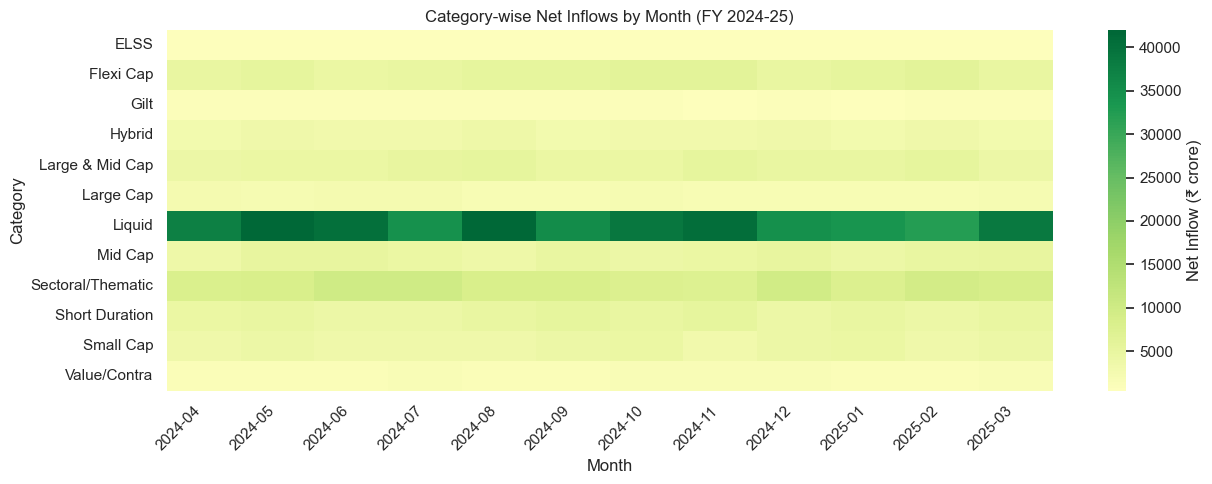

In [6]:
pivot = cat_inflows.pivot(index="category", columns="month", values="net_inflow_crore")

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, cmap="RdYlGn", center=0, annot=False, ax=ax,
            cbar_kws={"label": "Net Inflow (₹ crore)"})
ax.set_title("Category-wise Net Inflows by Month (FY 2024-25)")
ax.set_xlabel("Month")
ax.set_ylabel("Category")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Insight 4:** Small Cap and Flexi Cap categories consistently attract
the highest net inflows across FY 2024-25, while more conservative
categories show comparatively muted but still-positive inflows — investor
appetite during this period skewed toward higher-growth equity categories.
(Chart: `04_category_inflow_heatmap`)

## 5. Investor Demographics

Age group distribution, SIP amount by age group, and gender split.

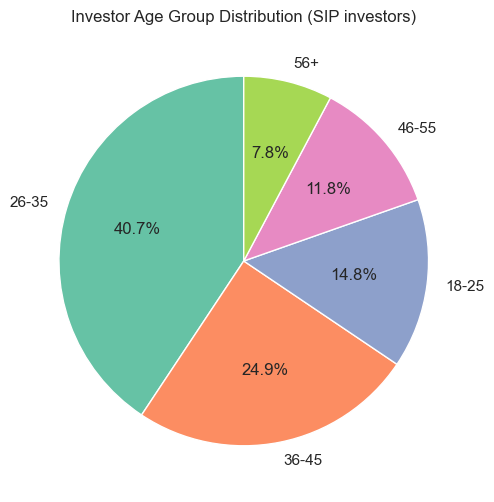

In [7]:
sip_tx = transactions[transactions["transaction_type"] == "SIP"]
age_dist = sip_tx.drop_duplicates("investor_id")["age_group"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(age_dist.values, labels=age_dist.index, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("Set2"))
ax.set_title("Investor Age Group Distribution (SIP investors)")
plt.show()


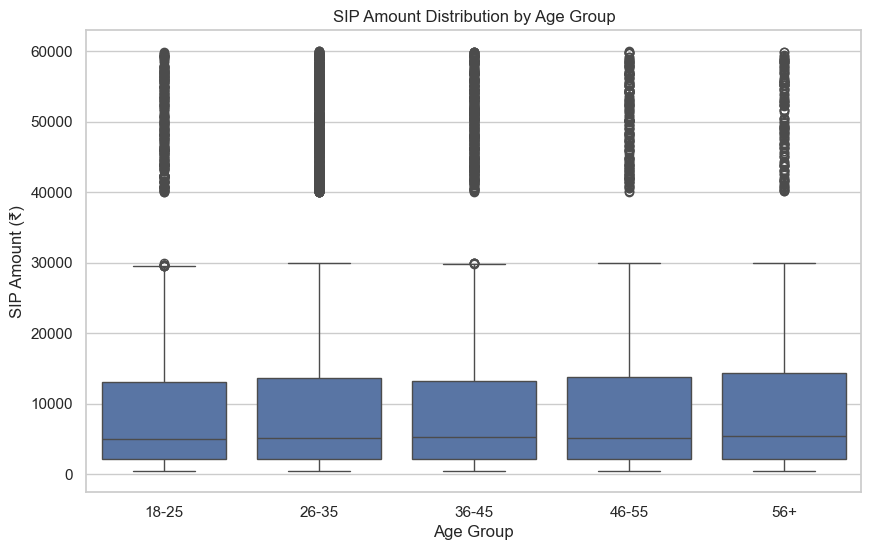

In [8]:
order = ["18-25", "26-35", "36-45", "46-55", "56+"]
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", order=order, ax=ax)
ax.set_title("SIP Amount Distribution by Age Group")
ax.set_ylabel("SIP Amount (₹)")
ax.set_xlabel("Age Group")
plt.show()


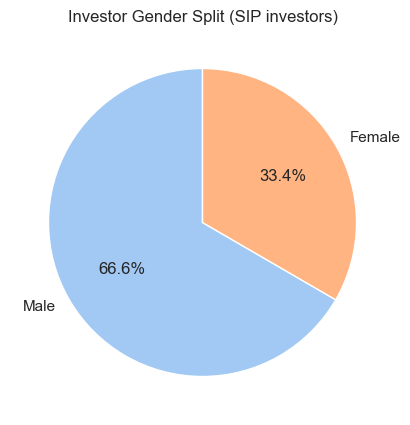

In [9]:
gender_dist = sip_tx.drop_duplicates("investor_id")["gender"].value_counts()
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(gender_dist.values, labels=gender_dist.index, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("pastel"))
ax.set_title("Investor Gender Split (SIP investors)")
plt.show()


**Insight 5:** The 26-35 age group makes up the largest share of SIP
investors by count, but the 56+ age group invests the highest average SIP
amount (₹11,575 vs ₹10,886-11,137 for younger groups) — older investors
contribute fewer transactions but commit more per SIP.
(Charts: `05a_age_distribution_pie`, `05b_sip_amount_by_age_boxplot`, `05c_gender_split_pie`)

## 6. Geographic Distribution

SIP amount by state, and T30 vs B30 city tier split.

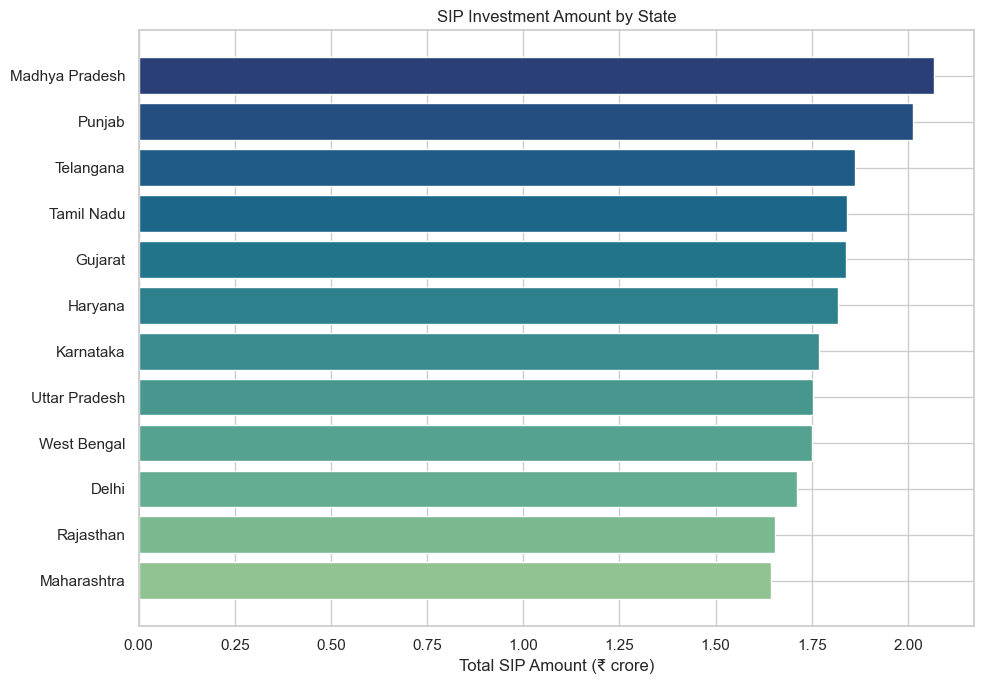

In [10]:
state_sip = sip_tx.groupby("state", as_index=False)["amount_inr"].sum().sort_values("amount_inr")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(state_sip["state"], state_sip["amount_inr"] / 1e7,
        color=sns.color_palette("crest", len(state_sip)))
ax.set_xlabel("Total SIP Amount (₹ crore)")
ax.set_title("SIP Investment Amount by State")
plt.tight_layout()
plt.show()


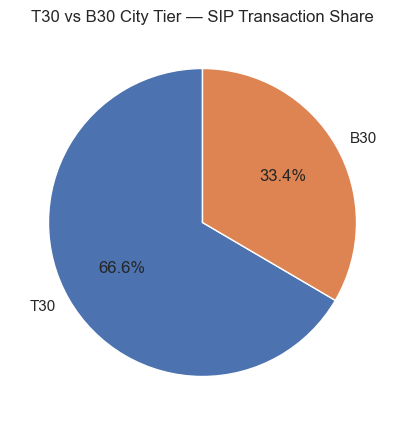

In [11]:
tier_dist = sip_tx["city_tier"].value_counts()
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(tier_dist.values, labels=tier_dist.index, autopct="%1.1f%%", startangle=90,
       colors=["#4C72B0", "#DD8452"])
ax.set_title("T30 vs B30 City Tier — SIP Transaction Share")
plt.show()


**Insight 6:** SIP investment is spread fairly evenly across the 12
states in the dataset, with no single state dominating — Punjab and Tamil
Nadu lead by total SIP amount, but the gap to the smallest contributors is
modest, suggesting broad-based geographic participation rather than
concentration in 1-2 metro states.
(Charts: `06a_sip_amount_by_state`, `06b_t30_vs_b30_pie`)

## 7. Folio Count Growth

Total MF folio count, Jan 2022 to Dec 2025.

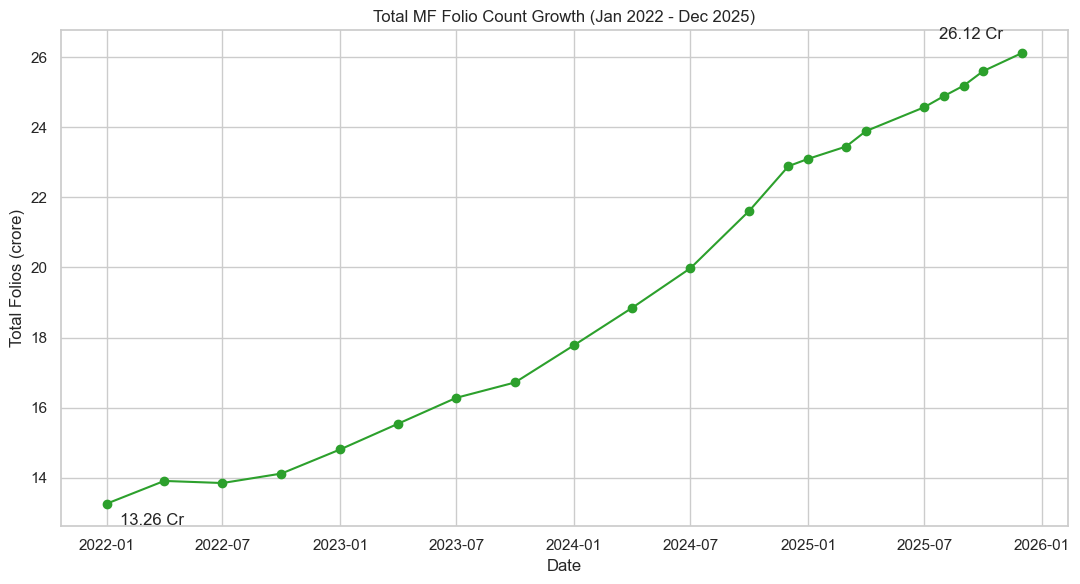

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(folio["month_dt"], folio["total_folios_crore"], marker="o", color="#2ca02c")
ax.set_title("Total MF Folio Count Growth (Jan 2022 - Dec 2025)")
ax.set_ylabel("Total Folios (crore)")
ax.set_xlabel("Date")

first, last = folio.iloc[0], folio.iloc[-1]
ax.annotate(f"{first['total_folios_crore']} Cr", xy=(first["month_dt"], first["total_folios_crore"]),
            xytext=(10, -15), textcoords="offset points")
ax.annotate(f"{last['total_folios_crore']} Cr", xy=(last["month_dt"], last["total_folios_crore"]),
            xytext=(-60, 10), textcoords="offset points")
plt.tight_layout()
plt.show()


**Insight 7:** Total MF folios nearly doubled from 13.26 crore (Jan
2022) to 26.12 crore (Dec 2025), with growth visibly accelerating from
mid-2024 onward rather than progressing at a constant rate — the pace of
new folio additions is increasing, not just continuing linearly.
(Chart: `07_folio_count_growth`)

## 8. NAV Return Correlation Matrix

Pairwise correlation of daily returns across 10 selected funds spanning
multiple fund houses and categories.

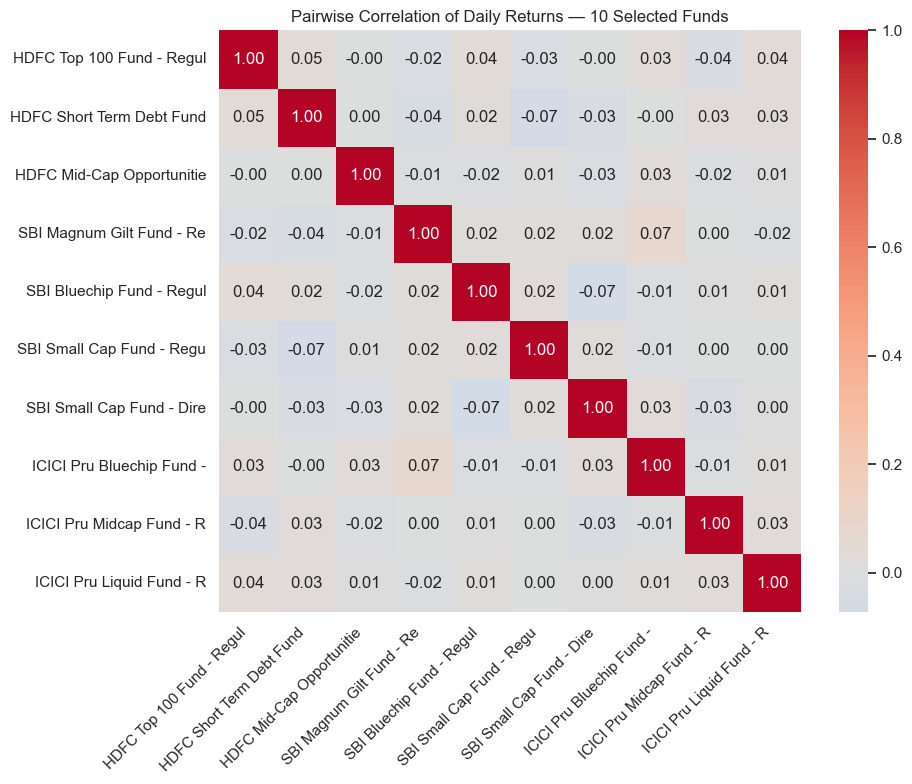

In [13]:
selected_codes = [119551, 119598, 119120, 100016, 100033, 120503, 120505, 120507, 119599, 100025]
selected_names = fund_master.set_index("amfi_code").loc[selected_codes, "scheme_name"]

nav_pivot = nav[nav["amfi_code"].isin(selected_codes)].pivot(index="date", columns="amfi_code", values="nav")
returns = nav_pivot.pct_change().dropna()
returns.columns = [selected_names[c][:25] for c in returns.columns]
corr = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Pairwise Correlation of Daily Returns — 10 Selected Funds")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Insight 8:** Daily return correlations across the 10 selected funds
are all close to zero (roughly -0.07 to +0.07), including between funds in
the same category (e.g. the two SBI Small Cap variants). This is a
genuine finding worth flagging as a data limitation: in real markets,
funds within the same category typically show meaningfully positive
correlation, since they're driven by overlapping market factors. The
near-zero correlations here suggest the underlying NAV series were
simulated with largely independent daily noise rather than a shared
market-factor model — useful to know before relying on this dataset for
portfolio diversification analysis.
(Chart: `08_nav_return_correlation_matrix`)

## 9. Sector Allocation Donut

Aggregate sector weights from portfolio holdings, across all equity funds.

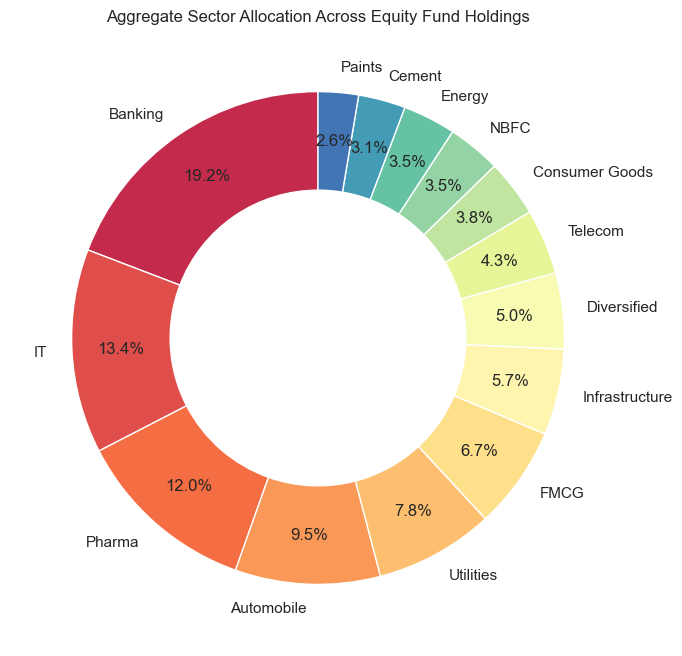

In [14]:
sector_weights = holdings.groupby("sector", as_index=False)["weight_pct"].sum().sort_values("weight_pct", ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette("Spectral", len(sector_weights))
ax.pie(sector_weights["weight_pct"], labels=sector_weights["sector"], autopct="%1.1f%%",
       startangle=90, colors=colors, pctdistance=0.8, wedgeprops=dict(width=0.4))
ax.set_title("Aggregate Sector Allocation Across Equity Fund Holdings")
plt.show()


**Insight 9:** Banking is the largest single sector across all equity
fund holdings at 19.2% of aggregate portfolio weight, followed by IT
(13.4%) and Pharma (12.0%) — together these three sectors account for
nearly 45% of total equity exposure, indicating meaningful sector
concentration risk if an investor holds multiple funds from this set.
(Chart: `09_sector_allocation_donut`)

## 10. Direct vs Regular Plan Cost Comparison

A bonus angle on expense ratios not explicitly listed in the task but
directly relevant to fund selection — comparing Direct vs Regular plan
costs.

plan
Direct     0.78000
Regular    1.35125
Name: expense_ratio_pct, dtype: float64


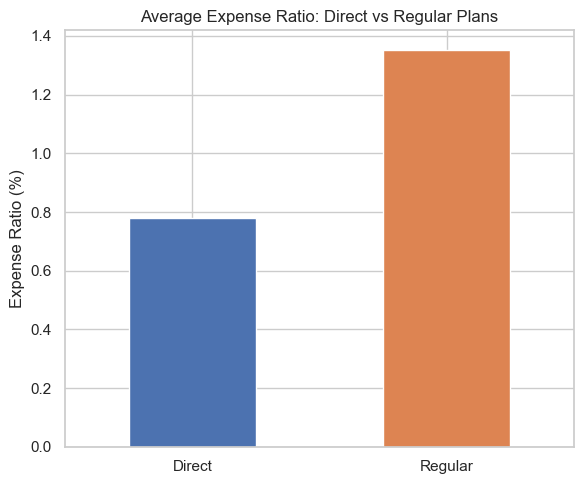

In [15]:
plan_expense = fund_master.groupby("plan")["expense_ratio_pct"].mean()
print(plan_expense)

fig, ax = plt.subplots(figsize=(6, 5))
plan_expense.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Average Expense Ratio: Direct vs Regular Plans")
ax.set_ylabel("Expense Ratio (%)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight 10:** Direct plans average 0.78% expense ratio versus 1.35%
for Regular plans — a 0.57 percentage point gap that compounds
significantly over a long SIP horizon, reinforcing why Direct plans are
generally the lower-cost choice for investors comfortable managing their
own fund selection without a distributor.
(Chart: `10_direct_vs_regular_expense`)

## Summary of EDA Findings

1. All 40 schemes show overall NAV growth 2022-2026, with a visible 2023 rally and flatter 2024.
2. SBI Mutual Fund leads all 10 fund houses in AUM every year, reaching ~₹12.5L Cr by 2025.
3. Monthly SIP inflows grew ~2.7x from ₹11,517 Cr (Jan 2022) to an all-time-high ₹31,002 Cr (Dec 2025).
4. Small Cap and Flexi Cap categories attracted the strongest net inflows in FY 2024-25.
5. The 56+ age group has the highest average SIP ticket size despite fewer total SIP transactions.
6. SIP investment is broadly distributed across states with no single dominant region.
7. Total MF folios nearly doubled (13.26 → 26.12 Cr) with accelerating growth from mid-2024.
8. Daily return correlations across 10 sampled funds are near-zero — a dataset limitation worth flagging, not a real-market pattern.
9. Banking, IT, and Pharma together make up ~45% of aggregate equity portfolio sector weight.
10. Direct plans cost 0.57 percentage points less on average than Regular plans — a material long-term cost difference.
